In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_step(f, y, t, h):
    """Un paso de RK4.

    f : función f(y, t) que devuelve dy/dt
    y : estado actual (array de NumPy)
    t : tiempo actual (escalar)
    h : tamaño de paso
    """
    k1 = f(y, t)
    k2 = f(y + h/2 * k1, t + h/2)
    k3 = f(y + h/2 * k2, t + h/2)
    k4 = f(y + h * k3,   t + h)
    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)


def integrar(f, y0, t_span, h):
    """Integra dy/dt = f(y,t) desde t_span[0] hasta t_span[1].

    y0     : condición inicial (array)
    t_span : (t_inicio, t_fin)
    h      : tamaño de paso
    """
    t_vals = np.arange(t_span[0], t_span[1], h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0

    for i in range(1, len(t_vals)):
        y_vals[i] = rk4_step(f, y_vals[i-1], t_vals[i-1], h)

    return t_vals, y_vals

### Ejemplo de uso: Resolución de `dy/dt = -y`

Vamos a resolver la ecuación diferencial `dy/dt = -y` con la condición inicial `y(0) = 1` en el intervalo de tiempo `t` de 0 a 5. La solución analítica de esta EDO es `y(t) = e^(-t)`.

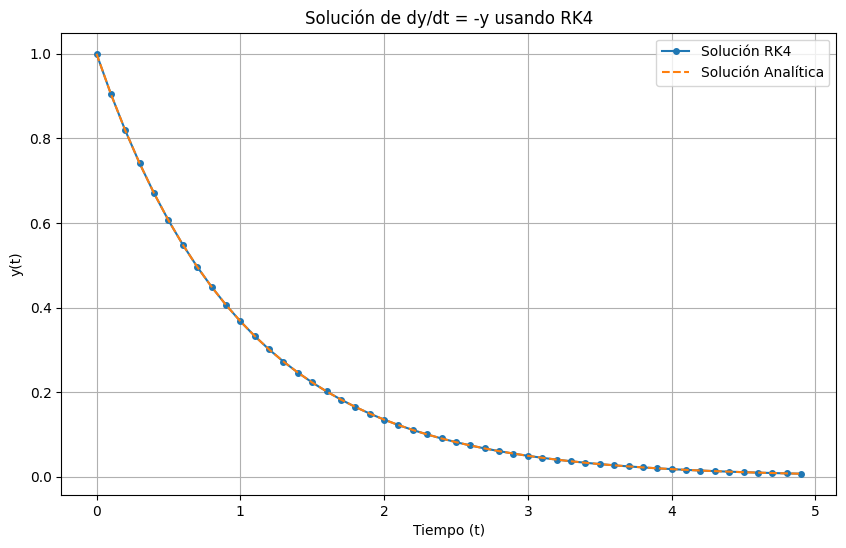

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la función f(y, t) = dy/dt para la EDO
def mi_edo(y, t):
    return -y

# 2. Definir la condición inicial, el rango de tiempo y el tamaño de paso
y0 = np.array([1.0])  # Condición inicial y(0) = 1
t_span = (0, 5)     # Integrar de t=0 a t=5
h = 0.1             # Tamaño de paso

# 3. Integrar la EDO usando la función 'integrar'
t_vals, y_vals = integrar(mi_edo, y0, t_span, h)

# 4. Obtener la solución analítica para comparar
y_analytical = np.exp(-t_vals)

# 5. Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(t_vals, y_vals[:, 0], label='Solución RK4', marker='o', markersize=4)
plt.plot(t_vals, y_analytical, label='Solución Analítica', linestyle='--')
plt.xlabel('Tiempo (t)')
plt.ylabel('y(t)')
plt.title('Solución de dy/dt = -y usando RK4')
plt.legend()
plt.grid(True)
plt.show()

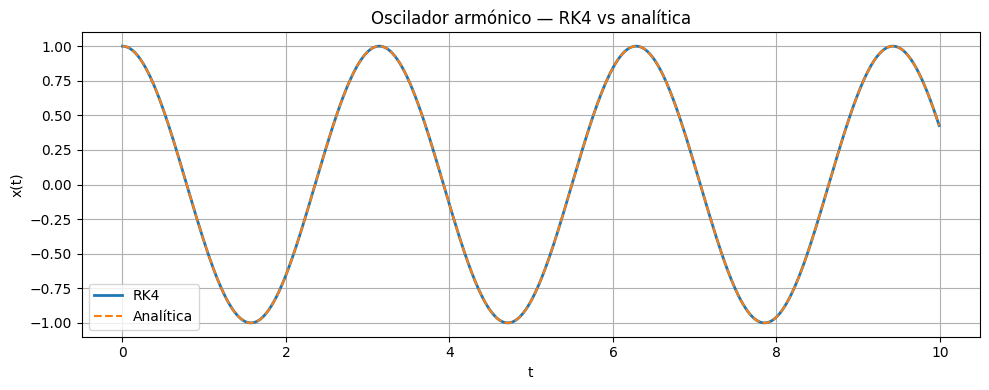

Error máximo RK4: 2.39e-08


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# [pega aquí rk4_step e integrar del bloque anterior]

# ══════════════════════════════════════════════════════
# SISTEMA 1: Oscilador armónico
# x'' + ω²x = 0
# Reescrito como sistema de primer orden:
#   y = [x, v]  →  dy/dt = [v, -ω²x]
# ══════════════════════════════════════════════════════

omega = 2.0

def rk4_step(f, y, t, h):
    k1 = f(y, t)
    k2 = f(y + h/2 * k1, t + h/2)
    k3 = f(y + h/2 * k2, t + h/2)
    k4 = f(y + h * k3,   t + h)
    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

def integrar(f, y0, t_span, h):
    t_vals = np.arange(t_span[0], t_span[1], h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0

    for i in range(1, len(t_vals)):
        y_vals[i] = rk4_step(f, y_vals[i-1], t_vals[i-1], h)

    return t_vals, y_vals

def oscilador(y, t):
    x, v = y
    return np.array([v, -omega**2 * x]) # Modificado para devolver un array de NumPy

# Condición inicial: x(0)=1, v(0)=0

y0 = np.array([1.0, 0.0])   # x(0)=1, v(0)=0
t, sol = integrar(oscilador, y0, t_span=(0, 10), h=0.01)

# Solución analítica para comparar
x_analitica = np.cos(omega * t)

plt.figure(figsize=(10, 4))
plt.plot(t, sol[:, 0], label='RK4', linewidth=2)
plt.plot(t, x_analitica, '--', label='Analítica', linewidth=1.5)
plt.xlabel('t'); plt.ylabel('x(t)')
plt.title('Oscilador armónico — RK4 vs analítica')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

# ¿Qué tan preciso es? Calcula el error máximo:
error_max = np.max(np.abs(sol[:, 0] - x_analitica))
print(f"Error máximo RK4: {error_max:.2e}")

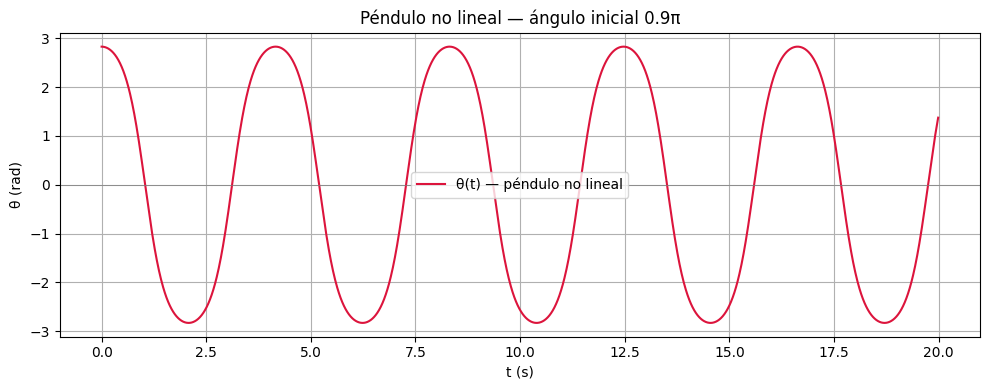

In [ ]:
# ══════════════════════════════════════════════════════
# SISTEMA 2: Péndulo no lineal (sin aproximación de ángulo pequeño)
#   θ'' + (g/L)sin(θ) = 0
#   y = [θ, ω]  →  dy/dt = [ω, -(g/L)sin(θ)]
# ══════════════════════════════════════════════════════

g = 9.81
L = 1.0

def pendulo(y, t):
    theta, omega = y
    return np.array([omega, -(g/L)*np.sin(theta)])

# Condición inicial: ángulo grande para ver efecto no lineal
y0_pendulo = np.array([np.pi * 0.9, 0.0])  # casi vertical
t2, sol2 = integrar(pendulo, y0_pendulo, t_span=(0, 20), h=0.01)

plt.figure(figsize=(10, 4))
plt.plot(t2, sol2[:, 0], label='θ(t) — péndulo no lineal', color='crimson')
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel('t (s)'); plt.ylabel('θ (rad)')
plt.title('Péndulo no lineal — ángulo inicial 0.9π')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

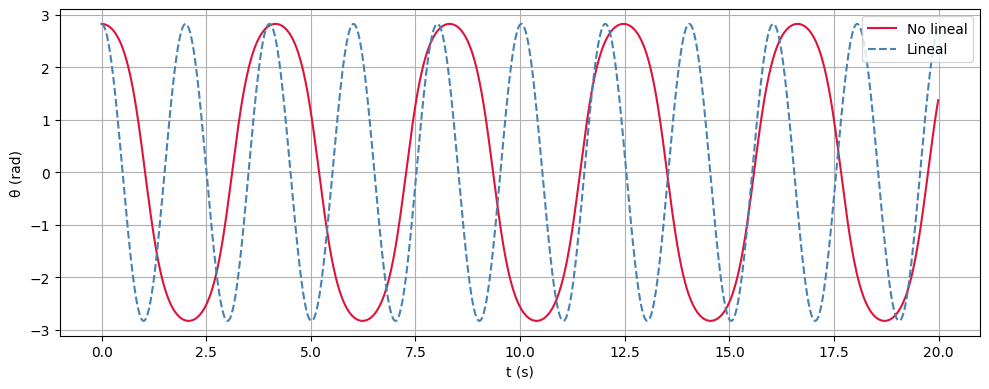

In [ ]:
# Compara lineal vs no lineal para el mismo ángulo inicial grande
def pendulo_lineal(y, t):
    theta, om = y
    return np.array([om, -(g/L)*theta])  # sin(θ) ≈ θ

t3, sol3 = integrar(pendulo_lineal, y0_pendulo, t_span=(0, 20), h=0.01)

plt.figure(figsize=(10, 4))
plt.plot(t2, sol2[:, 0], label='No lineal', color='crimson')
plt.plot(t3, sol3[:, 0], '--', label='Lineal', color='steelblue')
plt.xlabel('t (s)'); plt.ylabel('θ (rad)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()